# 01. データ探索 (Data Exploration)

このノートブックでは、競馬予測MLシステムのデータ概要を確認します。

## 目次
1. セットアップ
2. データの読み込み
3. 基本統計量の確認
4. 欠損値の分析
5. データ型の確認
6. レコード数の推移

## 1. セットアップ

In [1]:
# 必要なライブラリのインポート
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from google.cloud import bigquery
from dotenv import load_dotenv
import os
import warnings

warnings.filterwarnings('ignore')

# フォントキャッシュを再構築して日本語フォントを認識させる
font_manager._load_fontmanager(try_read_cache=False)

# プロット設定（スタイルを先に適用）
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# 日本語フォント設定（スタイル適用後に設定することが重要）
plt.rcParams['font.family'] = 'IPAexGothic'
plt.rcParams['axes.unicode_minus'] = False

# seabornのフォント設定も上書き
sns.set(font='IPAexGothic')

# 表示設定
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# 環境確認
print(f'Python: {sys.executable}')
print(f'Matplotlib font: {plt.rcParams["font.family"]}')
print('Setup complete!')

Python: /Users/michika_maruyama/Desktop/keiba_prediction/venv/bin/python
Matplotlib font: ['IPAexGothic']
Setup complete!


/Users/michika_maruyama/Desktop/keiba_prediction/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/michika_maruyama/Desktop/keiba_prediction/venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/michika_maruyama/Desktop/keiba_prediction/venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: 
    You are using a Python version 3.9 past its end of life. Google will update
    google-auth with critical bug fixes on a best-effort basis,

In [2]:
# 環境変数の読み込み
load_dotenv()

PROJECT_ID = os.environ.get('GCP_PROJECT_ID')
print(f'Project ID: {PROJECT_ID}')

# BigQueryクライアントの初期化
client = bigquery.Client(project=PROJECT_ID)

Project ID: keiba-prediction-1768734113


## 2. データの読み込み

BigQueryから各テーブルのデータを確認します。

In [3]:
# テーブル一覧を取得
def list_tables(dataset_id):
    """データセット内のテーブル一覧を取得"""
    tables = client.list_tables(f'{PROJECT_ID}.{dataset_id}')
    return [table.table_id for table in tables]

# rawデータセットのテーブル一覧
print('=== raw データセット ===')
try:
    raw_tables = list_tables('raw')
    for table in raw_tables:
        print(f'  - {table}')
except Exception as e:
    print(f'Error: {e}')

=== raw データセット ===
  - horse_extended
  - horse_master
  - horse_results
  - odds
  - pedigree
  - race_info
  - race_results
  - venue_info


In [4]:
# 各テーブルのレコード数を確認
def get_table_info(dataset_id, table_id):
    """テーブルの基本情報を取得"""
    query = f"""
    SELECT 
        COUNT(*) as row_count,
        MIN(race_date) as min_date,
        MAX(race_date) as max_date
    FROM `{PROJECT_ID}.{dataset_id}.{table_id}`
    """
    try:
        result = client.query(query).to_dataframe()
        return result.iloc[0].to_dict()
    except Exception as e:
        return {'error': str(e)}

# 主要テーブルの情報を取得
tables_to_check = [
    ('raw', 'race_info'),
    ('raw', 'horse_results'),
]

print('=== テーブル基本情報 ===')
for dataset_id, table_id in tables_to_check:
    info = get_table_info(dataset_id, table_id)
    print(f'\n{dataset_id}.{table_id}:')
    for key, value in info.items():
        print(f'  {key}: {value}')

=== テーブル基本情報 ===

raw.race_info:
  row_count: 6078
  min_date: 2016-01-09
  max_date: 2026-01-11

raw.horse_results:
  error: 400 Unrecognized name: race_date at [4:13]

Location: asia-northeast1
Job ID: 3fc565b0-a4bb-45c6-a404-54aedfc123a9



## 3. 基本統計量の確認

In [5]:
# race_infoテーブルのサンプルデータを取得
query_race_info = f"""
SELECT *
FROM `{PROJECT_ID}.raw.race_info`
LIMIT 1000
"""

df_race_info = client.query(query_race_info).to_dataframe()
print(f'race_info サンプル数: {len(df_race_info)}')
print(f'カラム数: {len(df_race_info.columns)}')
print(f'\nカラム一覧:')
print(df_race_info.columns.tolist())

race_info サンプル数: 1000
カラム数: 20

カラム一覧:
['race_id', 'race_date', 'venue_code', 'venue_name', 'race_number', 'race_name', 'course_type', 'distance', 'direction', 'race_class', 'age_condition', 'sex_condition', 'weather', 'track_condition', 'num_horses', 'prize_1st', 'prize_2nd', 'prize_3rd', 'created_at', 'updated_at']


In [6]:
# race_infoの基本統計量
print('=== race_info 基本統計量 ===')
df_race_info.describe()

=== race_info 基本統計量 ===


,race_number,distance,num_horses,prize_1st,prize_2nd,prize_3rd
count,1000.00,1000.00,930.00,0.00,0.00,0.00
mean,6.51,1690.33,8.06,<NA>,<NA>,<NA>
std,3.45,427.97,7.88,<NA>,<NA>,<NA>
min,1.00,1000.00,0.00,<NA>,<NA>,<NA>
25%,4.00,1400.00,0.00,<NA>,<NA>,<NA>
50%,7.00,1700.00,10.00,<NA>,<NA>,<NA>
75%,9.25,1800.00,16.00,<NA>,<NA>,<NA>
max,12.00,3900.00,84.00,<NA>,<NA>,<NA>


In [7]:
# horse_resultsテーブルのサンプルデータを取得
query_horse_results = f"""
SELECT *
FROM `{PROJECT_ID}.raw.horse_results`
LIMIT 1000
"""

df_horse_results = client.query(query_horse_results).to_dataframe()
print(f'horse_results サンプル数: {len(df_horse_results)}')
print(f'カラム数: {len(df_horse_results.columns)}')
print(f'\nカラム一覧:')
print(df_horse_results.columns.tolist())

horse_results サンプル数: 1000
カラム数: 120

カラム一覧:
['race_id', 'horse_number', 'horse_id', 'horse_name', 'idm', 'jockey_index', 'info_index', 'total_index', 'running_style', 'distance_aptitude', 'improvement', 'rotation', 'base_odds', 'base_popularity', 'base_place_odds', 'base_place_popularity', 'specific_mark_circle', 'specific_mark_circle2', 'specific_mark_triangle', 'specific_mark_triangle2', 'specific_mark_x', 'total_mark_circle', 'total_mark_circle2', 'total_mark_triangle', 'total_mark_triangle2', 'total_mark_x', 'popularity_index', 'training_index', 'stable_index', 'training_arrow_code', 'stable_eval_code', 'jockey_expected_win_rate', 'surge_index', 'hoof_code', 'heavy_aptitude_code', 'class_code', 'blinker', 'jockey_name', 'weight_carried', 'apprentice_class', 'trainer_name', 'trainer_affiliation', 'prev_race_key_1', 'prev_race_key_2', 'prev_race_key_3', 'prev_race_key_4', 'prev_race_key_5', 'bracket_number', 'overall_mark', 'idm_mark', 'info_mark', 'jockey_mark', 'stable_mark', 'trai

In [8]:
# horse_resultsの基本統計量
print('=== horse_results 基本統計量 ===')
df_horse_results.describe()

=== horse_results 基本統計量 ===


,horse_number,idm,jockey_index,info_index,total_index,running_style,distance_aptitude,improvement,rotation,base_odds,base_popularity,base_place_odds,base_place_popularity,specific_mark_circle,specific_mark_circle2,specific_mark_triangle,specific_mark_triangle2,specific_mark_x,total_mark_circle,total_mark_circle2,total_mark_triangle,total_mark_triangle2,total_mark_x,popularity_index,training_index,stable_index,training_arrow_code,stable_eval_code,jockey_expected_win_rate,surge_index,hoof_code,heavy_aptitude_code,class_code,weight_carried,apprentice_class,bracket_number,overall_mark,idm_mark,info_mark,jockey_mark,stable_mark,training_mark,surge_mark,prize_money,earned_prize,condition_class,ten_index,pace_index,agari_index,position_index,mid_position,mid_gap,mid_inside_outside,last_3f_position,last_3f_gap,last_3f_inside_outside,goal_position,goal_gap,goal_inside_outside,distance_aptitude_2,confirmed_weight,confirmed_weight_diff,cancel_flag,sex_code,owner_club_code,horse_symbol_code,surge_rank,ls_index_rank,ten_index_rank,pace_index_rank,agari_index_rank,position_index_rank,jockey_expected_win_single,jockey_expected_top3,body_total_1,body_total_2,body_total_3,horse_note_1,horse_note_2,horse_note_3,start_index,late_start_rate,big_ticket_index,big_ticket_mark,demotion_flag,rest_reason_code,stable_entry_race_count,stable_entry_days_before,stable_rank
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,889.00,0.00,0.00,1000.00,1000.00,393.00,1000.00,1000.00,0.00,0.00,1000.00,0.00,0.00,1000.00,0.00,1.00,1000.00,485.00,827.00,0.00,414.00,1000.00,487.00,1000.00,569.00,998.00,0.00,1000.00,143.00,889.00,606.00,595.00,555.00,605.00,606.00,1000.00,0.00,1000.00,1000.00,37.00,987.00,987.00,987.00,987.00,987.00,987.00,376.00,987.00,987.00,386.00,987.00,987.00,987.00,0.00,0.00,0.00,0.00,167.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
mean,7.88,36.32,0.78,0.67,37.79,2.73,3.64,<NA>,<NA>,26.87,4.20,5.42,8.13,0.39,<NA>,<NA>,0.43,<NA>,<NA>,0.45,<NA>,1.00,1.44,1.33,2.10,NaN,2.88,3.47,11.84,152.74,-0.25,3.04,<NA>,55.01,2.20,0.11,5.13,2.74,4.62,0.32,3.92,4.71,<NA>,46761.12,361.31,1.81,-15.49,-5.16,-12.31,-1.02,26.00,42.25,1.00,17.69,42.89,1.00,27.52,43.55,1.30,<NA>,<NA>,<NA>,<NA>,3.18,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
std,4.42,15.84,0.78,1.49,16.69,1.03,2.50,<NA>,<NA>,23.13,2.64,2.86,4.36,1.11,<NA>,<NA>,0.99,<NA>,<NA>,0.87,<NA>,<NA>,1.96,1.42,3.11,NaN,1.61,2.93,9.81,196.77,1.03,2.87,<NA>,1.72,0.79,0.66,0.48,1.55,2.35,0.47,3.05,2.27,<NA>,10744.50,66.50,1.37,8.99,9.91,10.95,9.08,29.00,28.83,0.00,24.55,29.28,0.00,29.45,29.21,1.63,<NA>,<NA>,<NA>,<NA>,1.35,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
min,1.00,0.00,0.00,-1.00,2.02,0.00,0.00,<NA>,<NA>,1.11,0.00,0.01,1.00,0.00,<NA>,<NA>,0.00,<NA>,<NA>,0.00,<NA>,1.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,-1.00,0.00,<NA>,49.00,1.00,0.00,3.00,1.00,1.00,0.00,0.00,1.00,<NA>,1810.00,178.00,1.00,-50.00,-55.00,-50.00,-9.90,0.00,2.00,1.00,0.00,2.00,1.00,0.00,1.00,0.00,<NA>,<NA>,<NA>,<NA>,2.00,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
25%,4.00,23.00,0.20,0.00,24.23,3.00,2.00,<NA>,<NA>,8.10,2.00,2.92,4.00,0.00,<NA>,<NA>,0.00,<NA>,<NA>,0.00,<NA>,1.00,0.00,0.00,0.00,NaN,1.00,1.00,3.00,12.00,-1.00,1.00,<NA>,54.00,2.00,0.00,5.00,2.00,3.00,0.00,1.00,3.00,<NA>,42210.00,315.00,1.00,-20.00,-12.00,-20.00,-7.80,3.00,18.00,1.00,3.00,14.00,1.00,3.00,21.00,0.00,<NA>,<NA>,<NA>,<NA>,2.00,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
50%,8.00,36.35,0.40,0.00,38.58,3.00,3.00,<NA>,<NA>,18.10,4.00,6.01,8.00,0.00,<NA>,<NA>,0.00,<NA>,<NA>,0.00,<NA>,1.00,0.00,1.00,1.00,NaN,3.00,3.00,10.00,73.00,-1.00,2.00,<NA>,55.00,2.00,0.00,5.00,2.00,5.00,0.00,3

## 4. 欠損値の分析

In [9]:
def analyze_missing_values(df, table_name):
    """欠損値の分析"""
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'カラム名': missing.index,
        '欠損数': missing.values,
        '欠損率(%)': missing_pct.values
    })
    missing_df = missing_df[missing_df['欠損数'] > 0].sort_values('欠損率(%)', ascending=False)
    
    print(f'\n=== {table_name} 欠損値分析 ===')
    print(f'総カラム数: {len(df.columns)}')
    print(f'欠損があるカラム数: {len(missing_df)}')
    
    if len(missing_df) > 0:
        print(f'\n欠損率が高いカラム（上位10件）:')
        display(missing_df.head(10))
        
        # 欠損率の可視化
        if len(missing_df) > 0:
            plt.figure(figsize=(12, 6))
            top_missing = missing_df.head(20)
            plt.barh(top_missing['カラム名'], top_missing['欠損率(%)'])
            plt.xlabel('欠損率 (%)')
            plt.title(f'{table_name} - 欠損率（上位20カラム）')
            plt.tight_layout()
            plt.show()
    else:
        print('欠損値はありません')
    
    return missing_df


=== race_info 欠損値分析 ===
総カラム数: 20
欠損があるカラム数: 6

欠損率が高いカラム（上位10件）:


,カラム名,欠損数,欠損率(%)
12,weather,1000,100.00
13,track_condition,1000,100.00
15,prize_1st,1000,100.00
16,prize_2nd,1000,100.00
17,prize_3rd,1000,100.00
14,num_horses,70,7.00


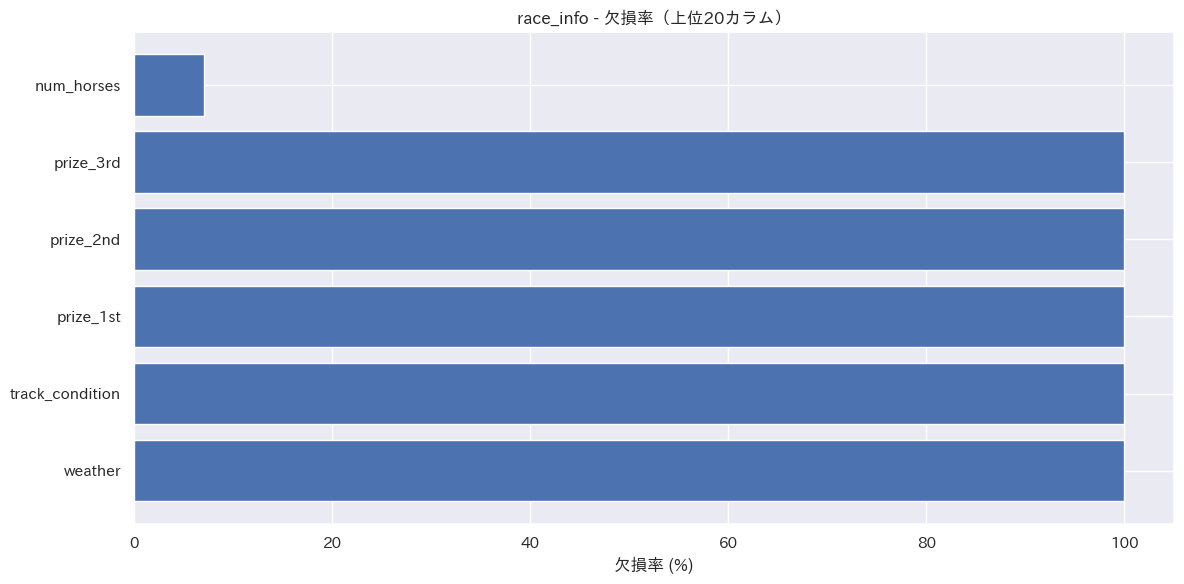

In [10]:
# race_infoの欠損値分析
missing_race_info = analyze_missing_values(df_race_info, 'race_info')


=== horse_results 欠損値分析 ===
総カラム数: 120
欠損があるカラム数: 91

欠損率が高いカラム（上位10件）:


,カラム名,欠損数,欠損率(%)
117,stable_rank,1000,100.00
105,reference_jockey_code,1000,100.00
80,cancel_flag,1000,100.00
79,confirmed_weight_diff,1000,100.00
78,confirmed_weight,1000,100.00
77,distance_aptitude_2,1000,100.00
103,late_start_rate,1000,100.00
104,reference_prev_race,1000,100.00
10,improvement,1000,100.00
84,horse_symbol_code,1000,100.00


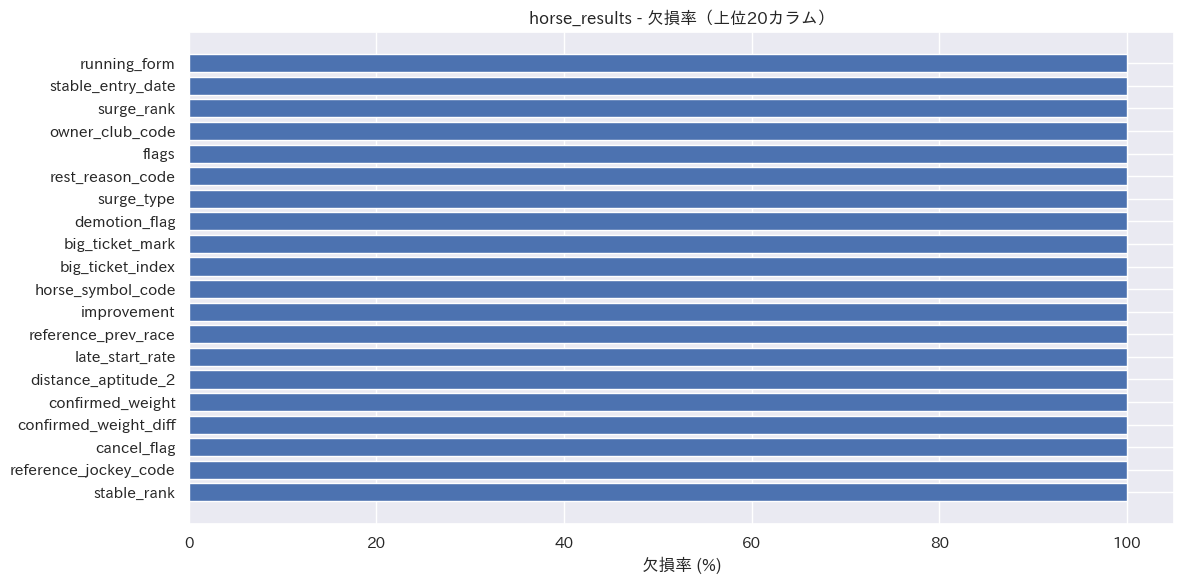

In [11]:
# horse_resultsの欠損値分析
missing_horse_results = analyze_missing_values(df_horse_results, 'horse_results')

## 5. データ型の確認

In [12]:
def analyze_data_types(df, table_name):
    """データ型の分析"""
    dtype_df = pd.DataFrame({
        'カラム名': df.columns,
        'データ型': df.dtypes.values,
        'ユニーク数': [df[col].nunique() for col in df.columns],
        'サンプル値': [df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else None for col in df.columns]
    })
    
    print(f'\n=== {table_name} データ型分析 ===')
    print(f'\nデータ型の分布:')
    print(df.dtypes.value_counts())
    
    return dtype_df

In [13]:
# race_infoのデータ型分析
dtype_race_info = analyze_data_types(df_race_info, 'race_info')
dtype_race_info.head(20)


=== race_info データ型分析 ===

データ型の分布:
object                 11
Int64                   6
datetime64[us, UTC]     2
dbdate                  1
Name: count, dtype: int64


,カラム名,データ型,ユニーク数,サンプル値
0,race_id,object,1000,08194409
1,race_date,dbdate,32,2019-10-13
2,venue_code,object,10,08
3,venue_name,object,10,京都
4,race_number,Int64,12,9
5,race_name,object,254,紫菊賞
6,course_type,object,3,turf
7,distance,Int64,35,2000
8,direction,object,3,right
9,race_class,object,9,Listed


In [14]:
# horse_resultsのデータ型分析
dtype_horse_results = analyze_data_types(df_horse_results, 'horse_results')
dtype_horse_results.head(20)


=== horse_results データ型分析 ===

データ型の分布:
Int64                  71
object                 29
float64                18
datetime64[us, UTC]     2
Name: count, dtype: int64


,カラム名,データ型,ユニーク数,サンプル値
0,race_id,object,72,02161401
1,horse_number,Int64,18,5
2,horse_id,object,978,13104543
3,horse_name,object,978,フジワンエンジェル
4,idm,float64,250,25.00
5,jockey_index,float64,36,1.10
6,info_index,float64,52,4.10
7,total_index,float64,767,30.22
8,running_style,Int64,4,3
9,distance_aptitude,Int64,10,2


## 6. レコード数の推移

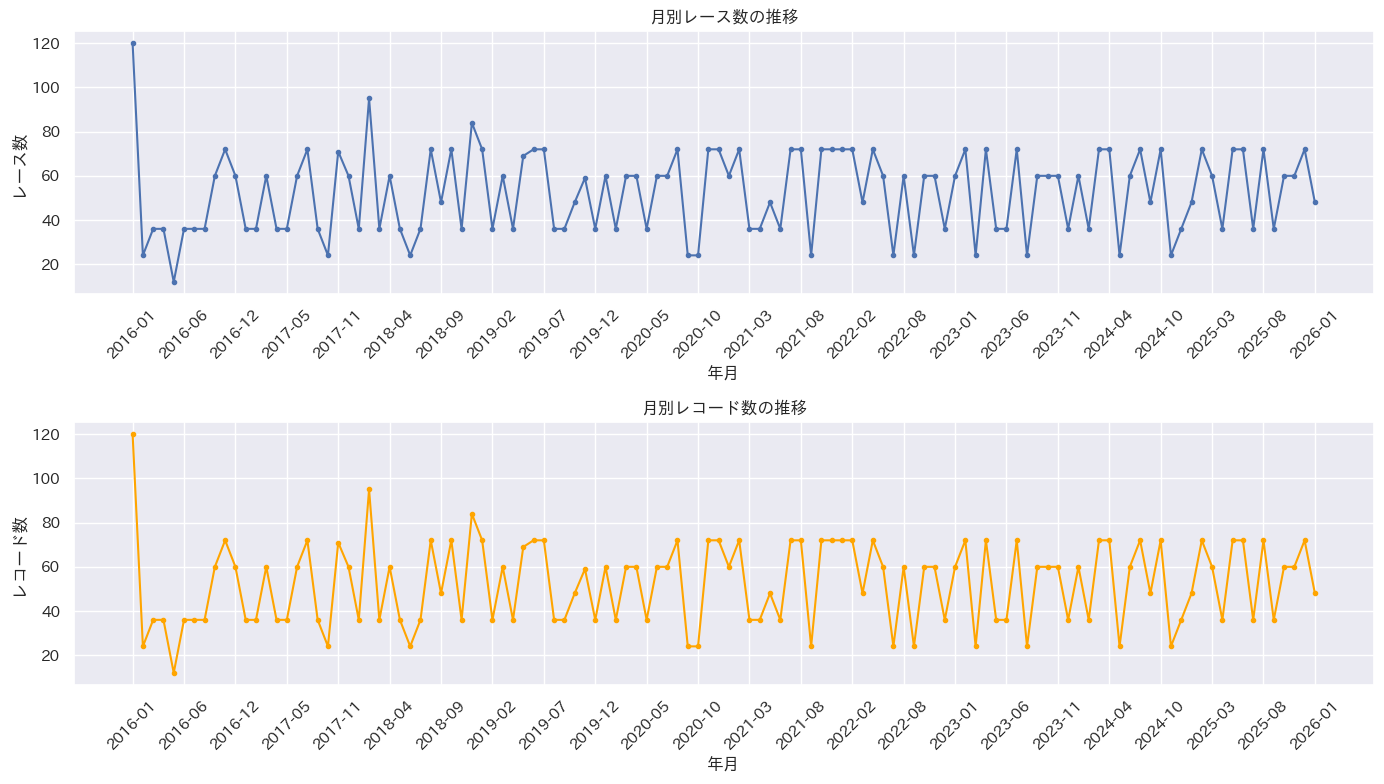


=== 月別統計サマリー ===
期間: 2016-01 ～ 2026-01
総月数: 116
月平均レース数: 52.4
月平均レコード数: 52.4


In [15]:
# 月別レコード数の推移を確認
query_monthly_counts = f"""
SELECT 
    FORMAT_DATE('%Y-%m', race_date) as year_month,
    COUNT(DISTINCT race_id) as race_count,
    COUNT(*) as total_records
FROM `{PROJECT_ID}.raw.race_info`
GROUP BY year_month
ORDER BY year_month
"""

try:
    df_monthly = client.query(query_monthly_counts).to_dataframe()
    
    # 可視化
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # レース数の推移
    axes[0].plot(df_monthly['year_month'], df_monthly['race_count'], marker='o', markersize=3)
    axes[0].set_title('月別レース数の推移')
    axes[0].set_xlabel('年月')
    axes[0].set_ylabel('レース数')
    axes[0].tick_params(axis='x', rotation=45)
    # X軸のラベルを間引く
    n = len(df_monthly)
    step = max(1, n // 20)
    axes[0].set_xticks(range(0, n, step))
    axes[0].set_xticklabels(df_monthly['year_month'].iloc[::step])
    
    # レコード数の推移
    axes[1].plot(df_monthly['year_month'], df_monthly['total_records'], marker='o', markersize=3, color='orange')
    axes[1].set_title('月別レコード数の推移')
    axes[1].set_xlabel('年月')
    axes[1].set_ylabel('レコード数')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_xticks(range(0, n, step))
    axes[1].set_xticklabels(df_monthly['year_month'].iloc[::step])
    
    plt.tight_layout()
    plt.show()
    
    print('\n=== 月別統計サマリー ===')
    print(f'期間: {df_monthly["year_month"].min()} ～ {df_monthly["year_month"].max()}')
    print(f'総月数: {len(df_monthly)}')
    print(f'月平均レース数: {df_monthly["race_count"].mean():.1f}')
    print(f'月平均レコード数: {df_monthly["total_records"].mean():.1f}')
except Exception as e:
    print(f'Error: {e}')

## まとめ

このノートブックでは以下の分析を行いました：

1. **テーブル構造の確認**: BigQueryに格納されているテーブル一覧とカラム情報
2. **基本統計量**: 数値カラムの分布（平均、標準偏差、最小/最大値など）
3. **欠損値分析**: 各カラムの欠損率と欠損パターン
4. **データ型分析**: 各カラムのデータ型とユニーク数
5. **時系列トレンド**: 月別のレコード数推移

### 次のステップ
- `02_race_analysis.ipynb`: レース条件と結果の関係分析
- `03_horse_analysis.ipynb`: 馬の成績分析
- `04_feature_correlation.ipynb`: 特徴量の相関分析